# MLOps & Model Deployment

# Part 0:  Reusing NYC Yellow Taxi Trip Records dataset

## Data Cleaning

### Step 1: Data Ingestion and Storage

In [1]:
from urllib.request import urlretrieve
from pathlib import Path

raw_dir = Path("data/raw")
raw_dir.mkdir(parents=True, exist_ok=True)

files = [
    ("https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet", raw_dir/"yellow_taxi_data.parquet"),
    ("https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv", raw_dir/"taxi_zone_lookup.csv"),
]

for url, filename in files:
    urlretrieve(url, filename)

print("Done!")

Done!


In [2]:
import polars as pl

df = pl.read_parquet(raw_dir/'yellow_taxi_data.parquet')
df.head()

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
i32,datetime[ns],datetime[ns],i64,f64,i64,str,i32,i32,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2,2024-01-01 00:57:55,2024-01-01 01:17:43,1,1.72,1,"""N""",186,79,2,17.7,1.0,0.5,0.0,0.0,1.0,22.7,2.5,0.0
1,2024-01-01 00:03:00,2024-01-01 00:09:36,1,1.8,1,"""N""",140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0
1,2024-01-01 00:17:06,2024-01-01 00:35:01,1,4.7,1,"""N""",236,79,1,23.3,3.5,0.5,3.0,0.0,1.0,31.3,2.5,0.0
1,2024-01-01 00:36:38,2024-01-01 00:44:56,1,1.4,1,"""N""",79,211,1,10.0,3.5,0.5,2.0,0.0,1.0,17.0,2.5,0.0
1,2024-01-01 00:46:51,2024-01-01 00:52:57,1,0.8,1,"""N""",211,148,1,7.9,3.5,0.5,3.2,0.0,1.0,16.1,2.5,0.0


In [3]:
import sys
expected_result = ["tpep_pickup_datetime", "tpep_dropoff_datetime", "PULocationID", "DOLocationID", "passenger_count", "trip_distance", "fare_amount", "tip_amount", "total_amount", "payment_type"]

try:
    missing = [m for m in expected_result if m not in df.columns]
    if missing:
        raise ValueError(f"Missing expected columns: {missing}")
    print("All columns present")

    if df.schema.get("tpep_pickup_datetime") != pl.Datetime:
        raise TypeError(f"tpep_pickup_datetime is {df.schema.get('tpep_pickup_datetime')}, expected Datetime")
    print("tpep_pickup_datetime datatype is: ", df.schema.get("tpep_pickup_datetime"))

    if df.schema.get("tpep_dropoff_datetime") != pl.Datetime:
        raise TypeError(f"tpep_dropoff_datetime is {df.schema.get('tpep_dropoff_datetime')}, expected Datetime")
    print("tpep_dropoff_datetime datatype is: ", df.schema.get("tpep_dropoff_datetime"))

    print(f'Number of rows: {len(df):,}')
    print(f'Number of columns: {len(df.columns)}')
    print('\nColumn names and types:')
    print(df.schema)

except Exception as e:
    print(f"Data Validation failed: {e}")
    sys.exit(1)


All columns present
tpep_pickup_datetime datatype is:  Datetime(time_unit='ns', time_zone=None)
tpep_dropoff_datetime datatype is:  Datetime(time_unit='ns', time_zone=None)
Number of rows: 2,964,624
Number of columns: 19

Column names and types:
Schema([('VendorID', Int32), ('tpep_pickup_datetime', Datetime(time_unit='ns', time_zone=None)), ('tpep_dropoff_datetime', Datetime(time_unit='ns', time_zone=None)), ('passenger_count', Int64), ('trip_distance', Float64), ('RatecodeID', Int64), ('store_and_fwd_flag', String), ('PULocationID', Int32), ('DOLocationID', Int32), ('payment_type', Int64), ('fare_amount', Float64), ('extra', Float64), ('mta_tax', Float64), ('tip_amount', Float64), ('tolls_amount', Float64), ('improvement_surcharge', Float64), ('total_amount', Float64), ('congestion_surcharge', Float64), ('Airport_fee', Float64)])


### Step 2: Data Transformation & Analysis

In [4]:
# ensuring the data is clean to avoid issues in analysis and visualizations
# removing nulls values in all columns
df_clean = df.drop_nulls()
print(f'Number of rows after dropping nulls: {len(df_clean):,}')
print(f'Number of rows removed after dropping nulls: {len(df) - len(df_clean):,}')

#filtering invalid trips: trips with zero or negative distance, negative fares, or fares exceeding $500
df_invalid = (
    df_clean
    .filter((pl.col("fare_amount") > 0) & (pl.col("fare_amount") <= 500))
    .filter(pl.col("trip_distance") > 0)
)
print(f'Number of rows after filtering invalid trips: {len(df_invalid):,}')
print(f'Number of rows removed after filtering invalid trips: {len(df_clean) - len(df_invalid):,}')

#removing trips where dropoff time is before pickup time
df_final = df_invalid.filter(pl.col("tpep_dropoff_datetime") >= pl.col("tpep_pickup_datetime"))
print(f'Number of rows after filtering dropoff before pickup: {len(df_final):,}')
print(f'Number of rows removed after filtering dropoff before pickup: {len(df_invalid) - len(df_final):,}')


Number of rows after dropping nulls: 2,824,462
Number of rows removed after dropping nulls: 140,162
Number of rows after filtering invalid trips: 2,754,435
Number of rows removed after filtering invalid trips: 70,027
Number of rows after filtering dropoff before pickup: 2,754,427
Number of rows removed after filtering dropoff before pickup: 8


In [5]:
#adding new column for trip duration in minutes
enriched = df_final.with_columns([
    ((pl.col("tpep_dropoff_datetime") - pl.col("tpep_pickup_datetime"))
    .dt.total_seconds() / 60).alias('trip_duration_minutes'),
])

enriched.select(pl.col("trip_duration_minutes")).head()

trip_duration_minutes
f64
19.8
6.6
17.916667
8.3
6.1


In [6]:
#adding new column for trip speed
enriched = enriched.with_columns([
    (
        pl.when(pl.col("trip_duration_minutes") > 0)
        .then(pl.col("trip_distance") / (pl.col("trip_duration_minutes") / 60))
        .otherwise(None)
        .alias('trip_speed_mph')
    )
])

enriched.select(pl.col("trip_speed_mph"))

trip_speed_mph
f64
5.212121
16.363636
15.739535
10.120482
7.868852
…
26.215768
12.205853
11.797418


In [7]:
#adding new columns for pickup hour and weekday
enriched = enriched.with_columns([
    pl.col('tpep_pickup_datetime').dt.hour().alias('pickup_hour'),
    pl.col('tpep_pickup_datetime').dt.weekday().alias('pickup_weekday')
])

enriched.select(pl.col("pickup_hour"), pl.col("pickup_weekday")).head()

pickup_hour,pickup_weekday
i8,i8
0,1
0,1
0,1
0,1
0,1


In [8]:
print(enriched.schema)

Schema([('VendorID', Int32), ('tpep_pickup_datetime', Datetime(time_unit='ns', time_zone=None)), ('tpep_dropoff_datetime', Datetime(time_unit='ns', time_zone=None)), ('passenger_count', Int64), ('trip_distance', Float64), ('RatecodeID', Int64), ('store_and_fwd_flag', String), ('PULocationID', Int32), ('DOLocationID', Int32), ('payment_type', Int64), ('fare_amount', Float64), ('extra', Float64), ('mta_tax', Float64), ('tip_amount', Float64), ('tolls_amount', Float64), ('improvement_surcharge', Float64), ('total_amount', Float64), ('congestion_surcharge', Float64), ('Airport_fee', Float64), ('trip_duration_minutes', Float64), ('trip_speed_mph', Float64), ('pickup_hour', Int8), ('pickup_weekday', Int8)])


In [9]:
print(enriched["payment_type"])

shape: (2_754_427,)
Series: 'payment_type' [i64]
[
	2
	1
	1
	1
	1
	…
	1
	1
	1
	2
	1
]


In [10]:
# filtering the dataset to include only credit card transactions for the modeling tasks
enriched = enriched.filter(pl.col("payment_type").is_in([1]))


In [11]:
print(enriched["payment_type"])

shape: (2_298_380,)
Series: 'payment_type' [i64]
[
	1
	1
	1
	1
	1
	…
	1
	1
	1
	1
	1
]


In [12]:
print(len(enriched))    #dropped from 2.9 mil to 2.2 mil after filtering for credit card transactions

2298380


In [13]:
enriched.write_parquet(raw_dir/'yellow_taxi_data_enriched.parquet')

## Data Preprocessing & Feature Engineering

### 1. Feature Engineering

In [14]:
#temporal features

enriched = enriched.with_columns([
    pl.col('tpep_pickup_datetime').dt.hour().alias('pickup_hour'),
    (pl.col('tpep_pickup_datetime').dt.weekday() - 1).alias('pickup_day_of_week')
])

#days of the week 0 - 6 so weekend is 5 and 6
enriched = enriched.with_columns(
    (pl.col('pickup_day_of_week') >= 5).alias('is_weekend')
)

enriched.select(["tpep_pickup_datetime","pickup_hour","pickup_day_of_week","is_weekend"]).sample(n=5)

tpep_pickup_datetime,pickup_hour,pickup_day_of_week,is_weekend
datetime[ns],i8,i8,bool
2024-01-23 17:49:11,17,1,false
2024-01-28 23:09:56,23,6,true
2024-01-18 09:08:13,9,3,false
2024-01-03 07:04:05,7,2,false
2024-01-10 15:32:03,15,2,false


In [15]:
#trip features

#trip duration minutes
enriched = enriched.with_columns([
    ((pl.col("tpep_dropoff_datetime") - pl.col("tpep_pickup_datetime"))
    .dt.total_seconds() / 60).alias('trip_duration_minutes')
])

#trip speed mph
enriched = enriched.with_columns([
    (
        pl.when(pl.col("trip_duration_minutes") > 0)
        .then(pl.col("trip_distance") / (pl.col("trip_duration_minutes") / 60))
        .otherwise(None)
        .alias('trip_speed_mph')
    )
])

#log trip distance
enriched = enriched.with_columns([
    pl.col("trip_distance").log1p().alias("log_trip_distance")
])

enriched.sample(n=5)

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,trip_duration_minutes,trip_speed_mph,pickup_hour,pickup_weekday,pickup_day_of_week,is_weekend,log_trip_distance
i32,datetime[ns],datetime[ns],i64,f64,i64,str,i32,i32,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i8,i8,i8,bool,f64
2,2024-01-11 12:45:32,2024-01-11 13:23:20,5,10.5,1,"""N""",237,264,1,47.8,0.0,0.5,10.0,0.0,1.0,61.8,2.5,0.0,37.8,16.666667,12,4,3,false,2.442347
2,2024-01-31 20:44:46,2024-01-31 20:53:25,1,1.08,1,"""N""",237,142,1,9.3,1.0,0.5,2.86,0.0,1.0,17.16,2.5,0.0,8.65,7.491329,20,3,2,false,0.732368
2,2024-01-25 00:31:06,2024-01-25 00:51:10,1,3.7,1,"""N""",114,256,1,21.9,1.0,0.5,5.38,0.0,1.0,32.28,2.5,0.0,20.066667,11.063123,0,4,3,false,1.547563
2,2024-01-28 15:07:55,2024-01-28 15:14:51,1,0.9,1,"""N""",246,186,1,7.9,0.0,0.5,2.98,0.0,1.0,14.88,2.5,0.0,6.933333,7.788462,15,7,6,true,0.641854
2,2024-01-21 14:10:53,2024-01-21 14:26:07,1,1.72,1,"""N""",164,158,1,14.9,0.0,0.5,2.0,0.0,1.0,20.9,2.5,0.0,15.233333,6.774617,14,7,6,true,1.000632


In [16]:
# fare features
#fare_per_mile
enriched = enriched.with_columns([
    (
        pl.when(pl.col("trip_distance") > 0)
        .then (pl.col("fare_amount") / pl.col("trip_distance"))
        .otherwise(None)
        .alias('fare_per_mile')
    )
])

#fare_per_minute
enriched = enriched.with_columns([
    (
        pl.when(pl.col("trip_duration_minutes") > 0)
        .then(pl.col("fare_amount") / pl.col("trip_duration_minutes"))
        .otherwise(None)
        .alias('fare_per_minute')
    )
])

enriched.sample(n=5)

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,trip_duration_minutes,trip_speed_mph,pickup_hour,pickup_weekday,pickup_day_of_week,is_weekend,log_trip_distance,fare_per_mile,fare_per_minute
i32,datetime[ns],datetime[ns],i64,f64,i64,str,i32,i32,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i8,i8,i8,bool,f64,f64,f64
2,2024-01-13 04:30:41,2024-01-13 04:40:45,1,3.01,1,"""N""",230,75,1,14.9,1.0,0.5,5.97,0.0,1.0,25.87,2.5,0.0,10.066667,17.940397,4,6,5,true,1.388791,4.950166,1.480132
2,2024-01-18 20:32:23,2024-01-18 20:52:35,2,2.74,1,"""N""",100,141,1,19.8,1.0,0.5,6.2,0.0,1.0,31.0,2.5,0.0,20.2,8.138614,20,4,3,false,1.319086,7.226277,0.980198
2,2024-01-23 10:17:42,2024-01-23 10:48:46,3,3.43,1,"""N""",107,142,1,28.2,0.0,0.5,3.0,0.0,1.0,35.2,2.5,0.0,31.066667,6.624464,10,2,1,false,1.4884,8.221574,0.907725
2,2024-01-06 11:42:01,2024-01-06 11:55:22,1,2.37,1,"""N""",234,231,1,14.9,0.0,0.5,4.8,0.0,1.0,23.7,2.5,0.0,13.35,10.651685,11,6,5,true,1.214913,6.28692,1.116105
2,2024-01-30 21:54:48,2024-01-30 21:58:25,1,0.54,1,"""N""",237,162,1,5.8,1.0,0.5,2.16,0.0,1.0,12.96,2.5,0.0,3.616667,8.958525,21,2,1,false,0.431782,10.740741,1.603687


In [17]:
df = pl.read_csv(raw_dir/'taxi_zone_lookup.csv')
df.head()

LocationID,Borough,Zone,service_zone
i64,str,str,str
1,"""EWR""","""Newark Airport""","""EWR"""
2,"""Queens""","""Jamaica Bay""","""Boro Zone"""
3,"""Bronx""","""Allerton/Pelham Gardens""","""Boro Zone"""
4,"""Manhattan""","""Alphabet City""","""Yellow Zone"""
5,"""Staten Island""","""Arden Heights""","""Boro Zone"""


In [18]:
#Zone features

# read zone table
zone_lookup = pl.read_csv(raw_dir/'taxi_zone_lookup.csv')

#join the zone lookup table to enriched table
enriched = enriched.join(
    zone_lookup.select([
        pl.col("LocationID"),
        pl.col("Borough")
    ]),
    left_on='PULocationID',
    right_on='LocationID',
    how='left'
).rename({'Borough': 'pickup_borough'})

enriched = enriched.join(
    zone_lookup.select([
        pl.col("LocationID"),
        pl.col("Borough")
    ]),
    left_on='DOLocationID',
    right_on='LocationID',
    how='left'
).rename({'Borough': 'dropoff_borough'})

enriched.sample(n=6)

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,trip_duration_minutes,trip_speed_mph,pickup_hour,pickup_weekday,pickup_day_of_week,is_weekend,log_trip_distance,fare_per_mile,fare_per_minute,pickup_borough,dropoff_borough
i32,datetime[ns],datetime[ns],i64,f64,i64,str,i32,i32,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i8,i8,i8,bool,f64,f64,f64,str,str
2,2024-01-23 18:42:04,2024-01-23 18:59:13,1,2.26,1,"""N""",162,234,1,16.3,2.5,0.5,4.1,0.0,1.0,26.9,2.5,0.0,17.15,7.906706,18,2,1,false,1.181727,7.212389,0.950437,"""Manhattan""","""Manhattan"""
2,2024-01-15 14:38:39,2024-01-15 14:43:20,1,0.54,1,"""N""",161,230,1,6.5,0.0,0.5,2.0,0.0,1.0,12.5,2.5,0.0,4.683333,6.918149,14,1,0,false,0.431782,12.037037,1.3879,"""Manhattan""","""Manhattan"""
2,2024-01-23 14:33:26,2024-01-23 14:59:53,2,2.84,1,"""N""",236,170,1,24.0,0.0,0.5,5.6,0.0,1.0,33.6,2.5,0.0,26.45,6.442344,14,2,1,false,1.345472,8.450704,0.907372,"""Manhattan""","""Manhattan"""
2,2024-01-30 16:12:24,2024-01-30 16:25:31,1,2.05,1,"""N""",234,229,1,14.2,2.5,0.5,4.14,0.0,1.0,24.84,2.5,0.0,13.116667,9.377382,16,2,1,false,1.115142,6.926829,1.082592,"""Manhattan""","""Manhattan"""
2,2024-01-23 16:13:12,2024-01-23 16:34:37,1,2.33,1,"""N""",140,48,1,19.8,2.5,0.5,5.26,0.0,1.0,31.56,2.5,0.0,21.416667,6.527626,16,2,1,false,1.202972,8.497854,0.924514,"""Manhattan""","""Manhattan"""
2,2024-01-31 14:32:07,2024-01-31 14:37:57,1,0.65,1,"""N""",237,237,1,7.2,0.0,0.5,2.24,0.0,1.0,13.44,2.5,0.0,5.833333,6.685714,14,3,2,false,0.500775,11.076923,1.234286,"""Manhattan""","""Manhattan"""


In [19]:
# convert from polars to pandas
import pandas as pd

enriched_pd = enriched.to_pandas()

enriched_pd.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,trip_speed_mph,pickup_hour,pickup_weekday,pickup_day_of_week,is_weekend,log_trip_distance,fare_per_mile,fare_per_minute,pickup_borough,dropoff_borough
0,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1,1.8,1,N,140,236,1,...,16.363636,0,1,0,False,1.029619,5.555556,1.515152,Manhattan,Manhattan
1,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1,4.7,1,N,236,79,1,...,15.739535,0,1,0,False,1.740466,4.957447,1.300465,Manhattan,Manhattan
2,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1,1.4,1,N,79,211,1,...,10.120482,0,1,0,False,0.875469,7.142857,1.204819,Manhattan,Manhattan
3,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1,0.8,1,N,211,148,1,...,7.868852,0,1,0,False,0.587787,9.875000,1.295082,Manhattan,Manhattan
4,1,2024-01-01 00:54:08,2024-01-01 01:26:31,1,4.7,1,N,148,141,1,...,8.708183,0,1,0,False,1.740466,6.297872,0.914050,Manhattan,Manhattan


In [20]:
from sklearn.preprocessing import OneHotEncoder
#ensure a regular dense array is returned and sklearn do not crash with unknown category
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

#look at columns and learn the categories
encoded_2d_array = ohe.fit_transform(enriched_pd[["pickup_borough", "dropoff_borough"]])

# to avoid the new columns being numbered 0,1,2...
encoded_cols = ohe.get_feature_names_out(["pickup_borough", "dropoff_borough"])

#turn encoded output to pandas table and add it to the enriched_pd dataframe
encoded_df = pd.DataFrame(encoded_2d_array, columns=encoded_cols, index=enriched_pd.index)
enriched_pd = pd.concat([enriched_pd, encoded_df], axis=1)

enriched_pd.sample(n=5)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,pickup_borough_Staten Island,pickup_borough_Unknown,dropoff_borough_Bronx,dropoff_borough_Brooklyn,dropoff_borough_EWR,dropoff_borough_Manhattan,dropoff_borough_N/A,dropoff_borough_Queens,dropoff_borough_Staten Island,dropoff_borough_Unknown
362076,2,2024-01-06 15:10:44,2024-01-06 15:54:40,2,17.16,2,N,132,90,1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1788854,2,2024-01-25 17:22:38,2024-01-25 17:35:57,1,1.13,1,N,246,164,1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2225523,2,2024-01-31 08:12:26,2024-01-31 08:30:50,2,2.12,1,N,142,140,1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
787695,2,2024-01-12 16:17:43,2024-01-12 16:25:43,1,1.39,1,N,238,142,1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1109262,1,2024-01-16 22:53:33,2024-01-16 23:07:38,1,2.60,1,N,230,262,1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


### 2. Target Variable Creation

In [21]:
# tip_amount (continuous, for regression)
y_reg = enriched_pd["tip_amount"]

#high_tip (binary: 1 if tip_amount > 20% of fare_amount, 0 otherwise, for classification
enriched_pd["high_tip"] = (
    (enriched_pd["tip_amount"] > 0) &
    (enriched_pd["tip_amount"] > 0.2 * enriched_pd["fare_amount"])
).astype(int)

y_clf = enriched_pd["high_tip"]

enriched_pd.sample(n=5)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,pickup_borough_Unknown,dropoff_borough_Bronx,dropoff_borough_Brooklyn,dropoff_borough_EWR,dropoff_borough_Manhattan,dropoff_borough_N/A,dropoff_borough_Queens,dropoff_borough_Staten Island,dropoff_borough_Unknown,high_tip
2238207,2,2024-01-31 11:24:41,2024-01-31 11:54:56,5,5.5,1,N,13,163,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1
786355,2,2024-01-12 16:44:43,2024-01-12 16:58:50,1,1.3,1,N,162,186,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1
2076520,1,2024-01-29 08:25:11,2024-01-29 08:37:33,1,1.7,1,N,162,140,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1
1377732,2,2024-01-20 10:29:41,2024-01-20 10:39:01,1,2.4,1,N,162,79,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
2152420,2,2024-01-30 10:27:05,2024-01-30 10:38:50,1,1.3,1,N,236,237,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1


In [22]:

enriched.select(["tip_amount", "fare_amount"]).sample(n=5)
print(enriched_pd["tip_amount"].max())
print(enriched_pd["fare_amount"].max())

422.7
485.0


### 3. Data Splitting & Scaling

In [23]:
#check max speed
print(f'Max speed: {enriched_pd["trip_speed_mph"].max()}')

Max speed: 41760.0


In [24]:
# Removing outliers
enriched_pd = enriched_pd[(enriched_pd["trip_speed_mph"] <= 100) & (enriched_pd["trip_speed_mph"] > 1)]
print(f'Max speed: {enriched_pd["trip_speed_mph"].max()}')
print(f'Min speed: {enriched_pd["trip_speed_mph"].min()}')

Max speed: 100.0
Min speed: 1.001545595054096


In [25]:
#Dropping columns
columns_to_drop = [
    "RatecodeID",
    "trip_distance",
    "total_amount"
    ]

enriched_pd = enriched_pd.drop(columns_to_drop, axis=1)

In [26]:
# Split data into training (70%), validation (15%), and test (15%) sets using stratified sampling for the classification target
from sklearn.model_selection import train_test_split

X= enriched_pd.drop(["tip_amount", "high_tip"], axis=1)
y_reg = enriched_pd["tip_amount"]
y_clf = enriched_pd["high_tip"]

X_train, X_temp, y_train_reg, y_temp_reg, y_train, y_temp = train_test_split(
    X, y_reg, y_clf, test_size=0.3, random_state=42, stratify=y_clf
)

X_val, X_test, y_val_reg, y_test_reg, y_val, y_test = train_test_split(
    X_temp, y_temp_reg, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [27]:
#identify column types
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "bool"]).columns.tolist()

print(f'Numeric features: {len(numeric_features)}')
print(f'Categorical features: {len(categorical_features)}')

Numeric features: 30
Categorical features: 4


In [28]:
# Apply StandardScaler to numeric features; fit on training data only
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

#numeric pipeline: impute missing values then scale
numeric_transformer = Pipeline(steps=[
  ('imputer', SimpleImputer(strategy='median')),
  ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
transformers=[
  ('num', numeric_transformer, numeric_features),
])

X_train_scaled = preprocessor.fit_transform(X_train)
X_val_scaled = preprocessor.transform(X_val)
X_test_scaled = preprocessor.transform(X_test)


In [29]:
included_features = numeric_features
excluded_by_preprocessor = [col for col in X.columns if col not in included_features]

print("Included in preprocessing:")
print(included_features)

print("\nExcluded by preprocessing:")
print(excluded_by_preprocessor)

Included in preprocessing:
['passenger_count', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tolls_amount', 'improvement_surcharge', 'congestion_surcharge', 'Airport_fee', 'trip_duration_minutes', 'trip_speed_mph', 'log_trip_distance', 'fare_per_mile', 'fare_per_minute', 'pickup_borough_Bronx', 'pickup_borough_Brooklyn', 'pickup_borough_EWR', 'pickup_borough_Manhattan', 'pickup_borough_N/A', 'pickup_borough_Queens', 'pickup_borough_Staten Island', 'pickup_borough_Unknown', 'dropoff_borough_Bronx', 'dropoff_borough_Brooklyn', 'dropoff_borough_EWR', 'dropoff_borough_Manhattan', 'dropoff_borough_N/A', 'dropoff_borough_Queens', 'dropoff_borough_Staten Island', 'dropoff_borough_Unknown']

Excluded by preprocessing:
['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'pickup_hour', 'pickup_weekday', 'pickup_day_of_week', 'is_weekend', 'pickup_borough', 'dropoff_borough']


In [30]:
#Document the number of samples in each split and the class distribution of high_tip in each split
print("Number of samples in each split:")
print("Training set size:", len(X_train))
print("Validation set size:", len(X_val))
print("Test set size:", len(X_test))

print("\nClass distribution of high_tip in Training set:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

print("\nClass distribution of high_tip in Validation set:")
print(y_val.value_counts())
print(y_val.value_counts(normalize=True))

print("\nClass distribution of high_tip in Test set:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True))

Number of samples in each split:
Training set size: 1607057
Validation set size: 344369
Test set size: 344370

Class distribution of high_tip in Training set:
high_tip
1    1220853
0     386204
Name: count, dtype: int64
high_tip
1    0.759682
0    0.240318
Name: proportion, dtype: float64

Class distribution of high_tip in Validation set:
high_tip
1    261611
0     82758
Name: count, dtype: int64
high_tip
1    0.759682
0    0.240318
Name: proportion, dtype: float64

Class distribution of high_tip in Test set:
high_tip
1    261612
0     82758
Name: count, dtype: int64
high_tip
1    0.759683
0    0.240317
Name: proportion, dtype: float64


#### Print a summary of feature names, types, and any features excluded from modeling (and why)

In [31]:
print("Feature names used for modeling:")
print(numeric_features)
print("Number of features used:", len(numeric_features))

Feature names used for modeling:
['passenger_count', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tolls_amount', 'improvement_surcharge', 'congestion_surcharge', 'Airport_fee', 'trip_duration_minutes', 'trip_speed_mph', 'log_trip_distance', 'fare_per_mile', 'fare_per_minute', 'pickup_borough_Bronx', 'pickup_borough_Brooklyn', 'pickup_borough_EWR', 'pickup_borough_Manhattan', 'pickup_borough_N/A', 'pickup_borough_Queens', 'pickup_borough_Staten Island', 'pickup_borough_Unknown', 'dropoff_borough_Bronx', 'dropoff_borough_Brooklyn', 'dropoff_borough_EWR', 'dropoff_borough_Manhattan', 'dropoff_borough_N/A', 'dropoff_borough_Queens', 'dropoff_borough_Staten Island', 'dropoff_borough_Unknown']
Number of features used: 30


In [32]:
print("\nFeature data types:")
print(X[numeric_features].dtypes)
# print(X.dtypes)

print("\nCount of each data type:")
print(X.dtypes.value_counts())


Feature data types:
passenger_count                    int64
payment_type                       int64
fare_amount                      float64
extra                            float64
mta_tax                          float64
tolls_amount                     float64
improvement_surcharge            float64
congestion_surcharge             float64
Airport_fee                      float64
trip_duration_minutes            float64
trip_speed_mph                   float64
log_trip_distance                float64
fare_per_mile                    float64
fare_per_minute                  float64
pickup_borough_Bronx             float64
pickup_borough_Brooklyn          float64
pickup_borough_EWR               float64
pickup_borough_Manhattan         float64
pickup_borough_N/A               float64
pickup_borough_Queens            float64
pickup_borough_Staten Island     float64
pickup_borough_Unknown           float64
dropoff_borough_Bronx            float64
dropoff_borough_Brooklyn         flo

In [33]:
print(f"\nNumeric features ({len(numeric_features)}):")
print(numeric_features)

print(f"\nCategorical features ({len(categorical_features)}):")
print(categorical_features)


Numeric features (30):
['passenger_count', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tolls_amount', 'improvement_surcharge', 'congestion_surcharge', 'Airport_fee', 'trip_duration_minutes', 'trip_speed_mph', 'log_trip_distance', 'fare_per_mile', 'fare_per_minute', 'pickup_borough_Bronx', 'pickup_borough_Brooklyn', 'pickup_borough_EWR', 'pickup_borough_Manhattan', 'pickup_borough_N/A', 'pickup_borough_Queens', 'pickup_borough_Staten Island', 'pickup_borough_Unknown', 'dropoff_borough_Bronx', 'dropoff_borough_Brooklyn', 'dropoff_borough_EWR', 'dropoff_borough_Manhattan', 'dropoff_borough_N/A', 'dropoff_borough_Queens', 'dropoff_borough_Staten Island', 'dropoff_borough_Unknown']

Categorical features (4):
['store_and_fwd_flag', 'is_weekend', 'pickup_borough', 'dropoff_borough']


In [34]:
excluded_features = [col for col in X.columns if col not in numeric_features]

print("\nExcluded features:")
print(excluded_features)
print("Number of excluded features:", len(excluded_features))


Excluded features:
['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'pickup_hour', 'pickup_weekday', 'pickup_day_of_week', 'is_weekend', 'pickup_borough', 'dropoff_borough']
Number of excluded features: 12


In [35]:
print("\nExcluded features:")
print("\ntip_amount was excluded because it is a regression target and would cause target leakage")
print("\nhigh_tip was excluded because it is a classification target and would cause target leakage")
print("\nVendorID was excluded it is an identifier and not included in the numeric preprocessing pipepline")
print("\ntpep_pickup_datetime was excluded because it is a date and not included in the numeric preprocessing pipepline")
print("\ntpep_dropoff_datetime was excluded because it is a date and not included in the numeric preprocessing pipepline")
print("\nstore_and_fwd_flag, is_weekend, pickup_borough and dropoff_borough was excluded because it is categorical")
print("\nPULocationID was excluded because it is a identifier")
print("\nDOLocationID was excluded because it is a identifier")
print("\npickup_hour, pickup_weekday and pickup_day_of_week was excluded because the data type is int8 and only data type int64 and float64 was included in the pipeline")


Excluded features:

tip_amount was excluded because it is a regression target and would cause target leakage

high_tip was excluded because it is a classification target and would cause target leakage

VendorID was excluded it is an identifier and not included in the numeric preprocessing pipepline

tpep_pickup_datetime was excluded because it is a date and not included in the numeric preprocessing pipepline

tpep_dropoff_datetime was excluded because it is a date and not included in the numeric preprocessing pipepline

store_and_fwd_flag, is_weekend, pickup_borough and dropoff_borough was excluded because it is categorical

PULocationID was excluded because it is a identifier

DOLocationID was excluded because it is a identifier

pickup_hour, pickup_weekday and pickup_day_of_week was excluded because the data type is int8 and only data type int64 and float64 was included in the pipeline


## Part 1: Experiment Tracking with MLflow

In [36]:
# MLflow Setup & Experiment Logging
import mlflow

# Set MLflow to log local tracking server
mlflow.set_tracking_uri("http://127.0.0.1:5000")
print("MLflow tracking URI set to:", mlflow.get_tracking_uri())

# Create  the experiment
experiment_name = "taxi-tip-prediction"
experiment_id = mlflow.set_experiment(experiment_name)
print(f"MLflow experiment set: {experiment_name}")

MLflow tracking URI set to: http://127.0.0.1:5000
MLflow experiment set: taxi-tip-prediction


### Model Training 

In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score
)
import numpy as np
import pandas as pd
import mlflow.sklearn
import os
import joblib

In [38]:
#define regression models
reg_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=50, random_state=42)
   }


In [39]:
model_dir = "models"
os.makedirs(model_dir, exist_ok=True)

# Sample 300,000 rows from train and test sets (if they have more than 300,000 rows)
n_sample = 300_000

X_train_sample = X_train.sample(n=n_sample, random_state=42) if len(X_train) > n_sample else X_train
y_train_reg_sample = y_train_reg.loc[X_train_sample.index]

X_test_sample = X_test.sample(n=n_sample, random_state=42) if len(X_test) > n_sample else X_test
y_test_reg_sample = y_test_reg.loc[X_test_sample.index]

for name, reg_model in reg_models.items():
    with mlflow.start_run(run_name=name):
        print(f"Training {name} on {len(X_train_sample)} rows...")
        pipe = Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("regressor", reg_model)
        ])

        pipe.fit(X_train_sample, y_train_reg_sample)
        y_test_pred = pipe.predict(X_test_sample)

        # Log hyperparameters
        if hasattr(reg_model, "get_params"):
            params = reg_model.get_params()
            for param_name, param_value in params.items():
                mlflow.log_param(param_name, param_value)

        # Log metrics
        mae = mean_absolute_error(y_test_reg_sample, y_test_pred)
        rmse = np.sqrt(mean_squared_error(y_test_reg_sample, y_test_pred))
        r2 = r2_score(y_test_reg_sample, y_test_pred)
        mlflow.log_metric("MAE", mae)
        mlflow.log_metric("RMSE", rmse)
        mlflow.log_metric("R2", r2)

        # Log model artifact to MLflow
        mlflow.sklearn.log_model(pipe, "model")

        # Save model artifact locally
        artifact = {
            "model": pipe,
            "model_name": f"taxi-tip-{name.lower().replace(' ', '-')}",
            "feature_names": list(X_train.columns),
            "metrics": {"MAE": mae, "RMSE": rmse, "R2": r2},
            "target_name": "tip_amount"
        }
        filename = f"{name.lower().replace(' ', '_')}_artifact.pkl"
        save_path = os.path.join(model_dir, filename)
        joblib.dump(artifact, save_path)
        print(f"Regression model artifact saved as {name} to {save_path}")

        # Log tags
        mlflow.set_tag("model_type", name)
        mlflow.set_tag("dataset_version", "v1") 

        print(f"{name} run logged to MLflow.")

print("All models trained, logged to MLflow, and saved locally.")

Training Linear Regression on 300000 rows...


2026/04/17 18:27:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/17 18:27:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Regression model artifact saved as Linear Regression to models\linear_regression_artifact.pkl
Linear Regression run logged to MLflow.
🏃 View run Linear Regression at: http://127.0.0.1:5000/#/experiments/1/runs/00dc14b6c0a04271a183c98696d6f9f3
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Training Random Forest Regressor on 300000 rows...


2026/04/17 18:29:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/17 18:29:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Regression model artifact saved as Random Forest Regressor to models\random_forest_regressor_artifact.pkl
Random Forest Regressor run logged to MLflow.
🏃 View run Random Forest Regressor at: http://127.0.0.1:5000/#/experiments/1/runs/fe6e02d48e6c472c94d10fea7327eefa
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
All models trained, logged to MLflow, and saved locally.


### Display a screenshot of the MLflow UI showing all logged runs

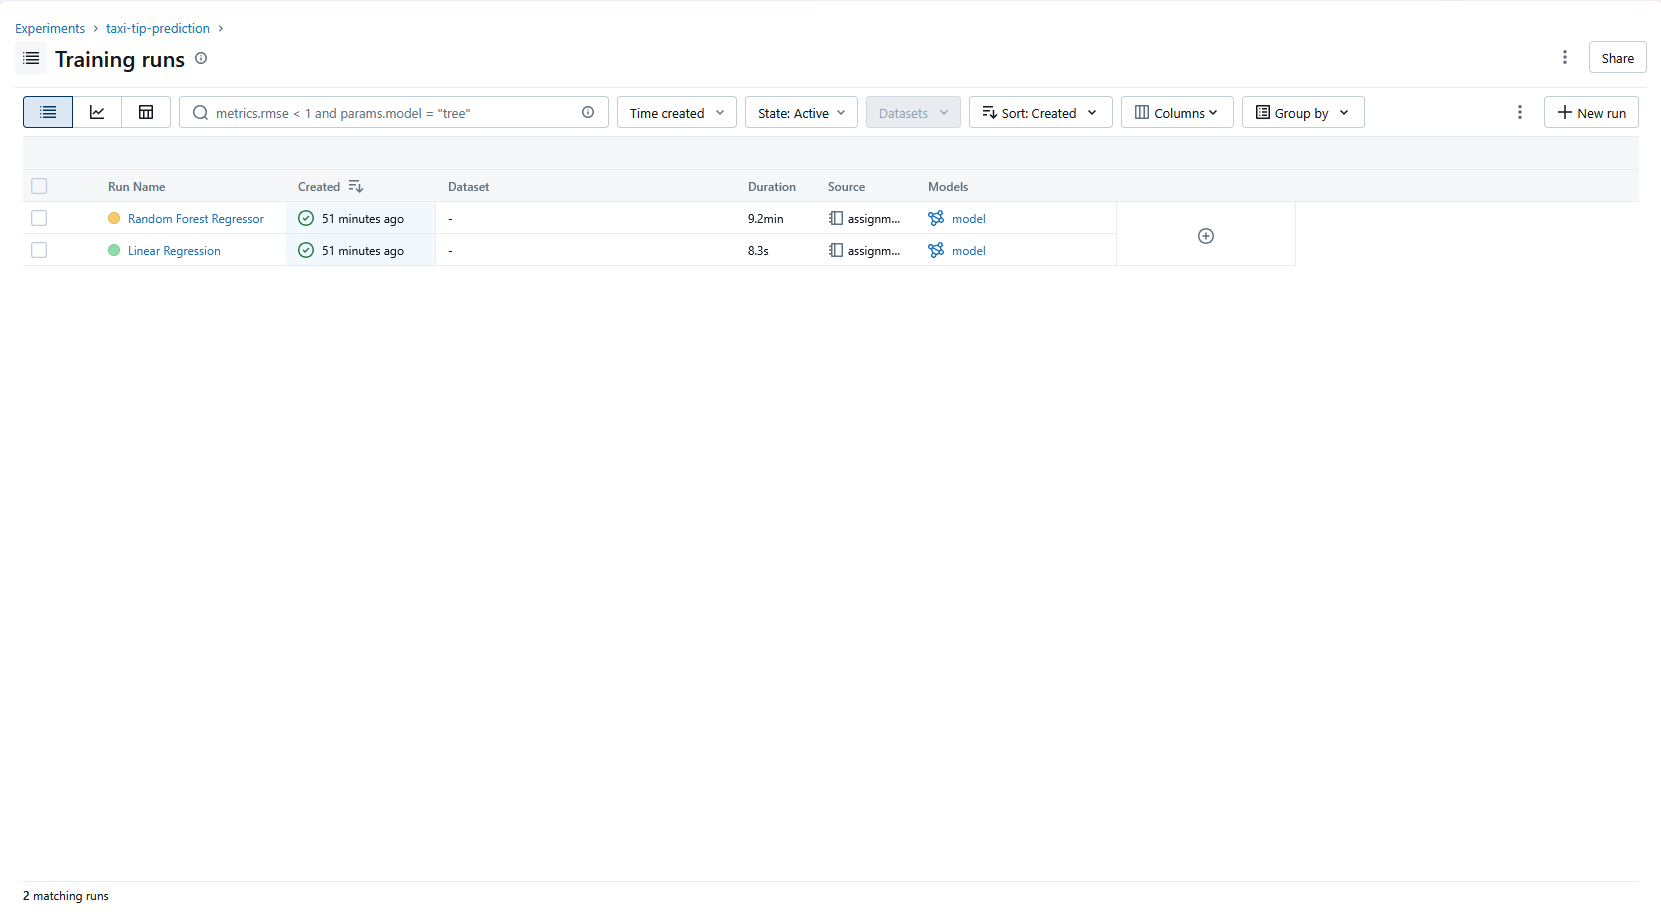

## Model Comparison & Registry

### MLflow UI comparing all logged runs side-by-side

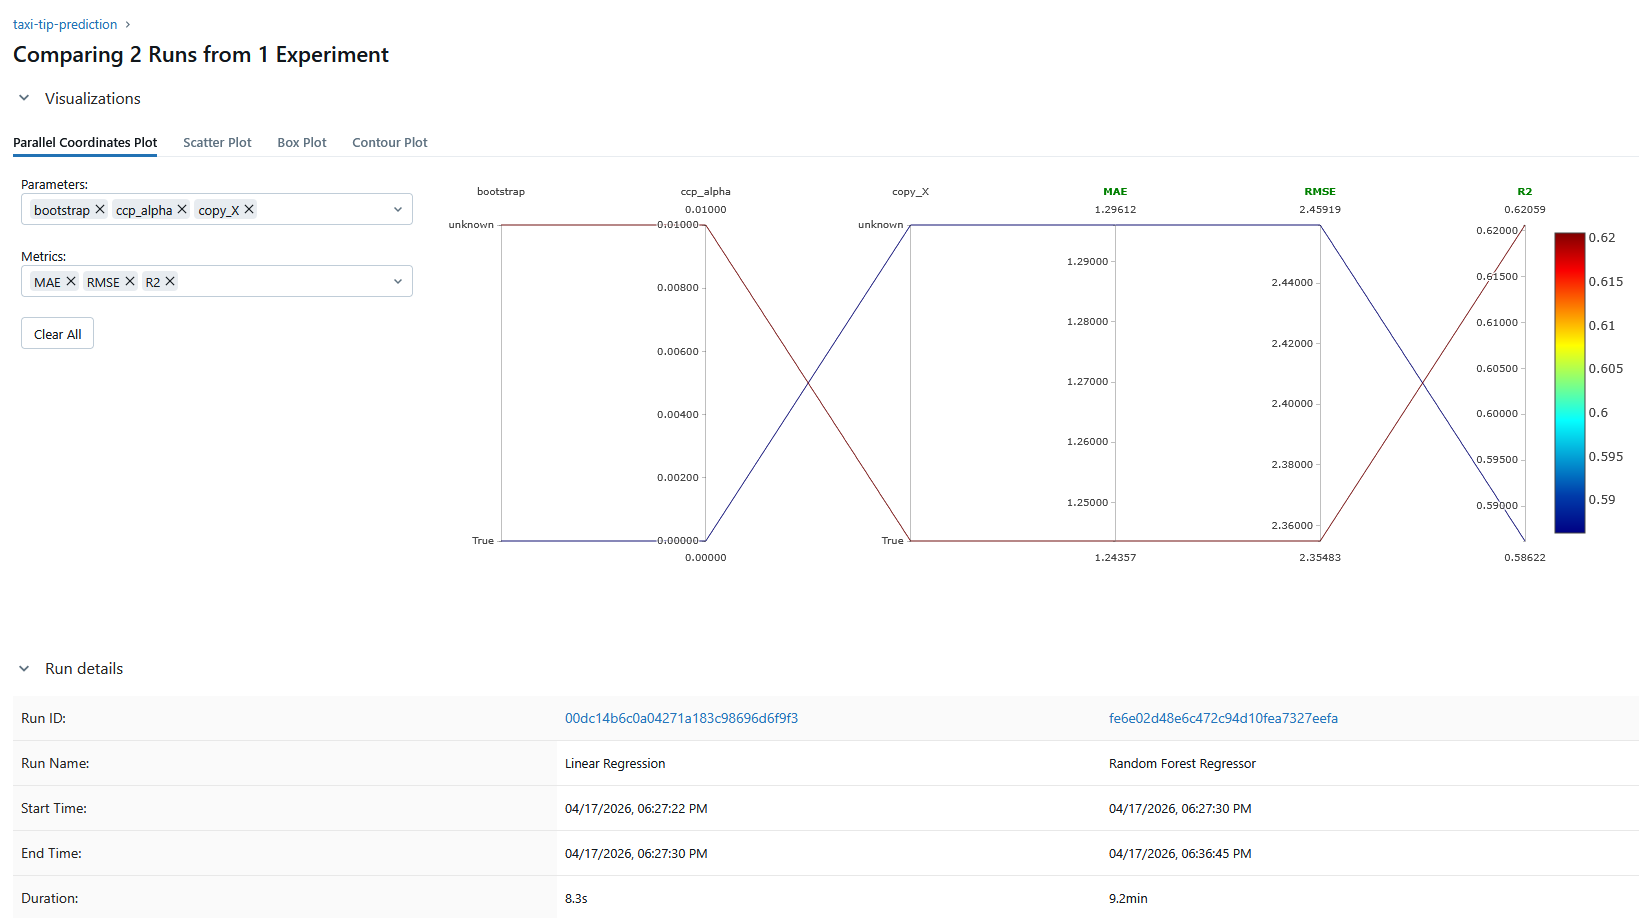
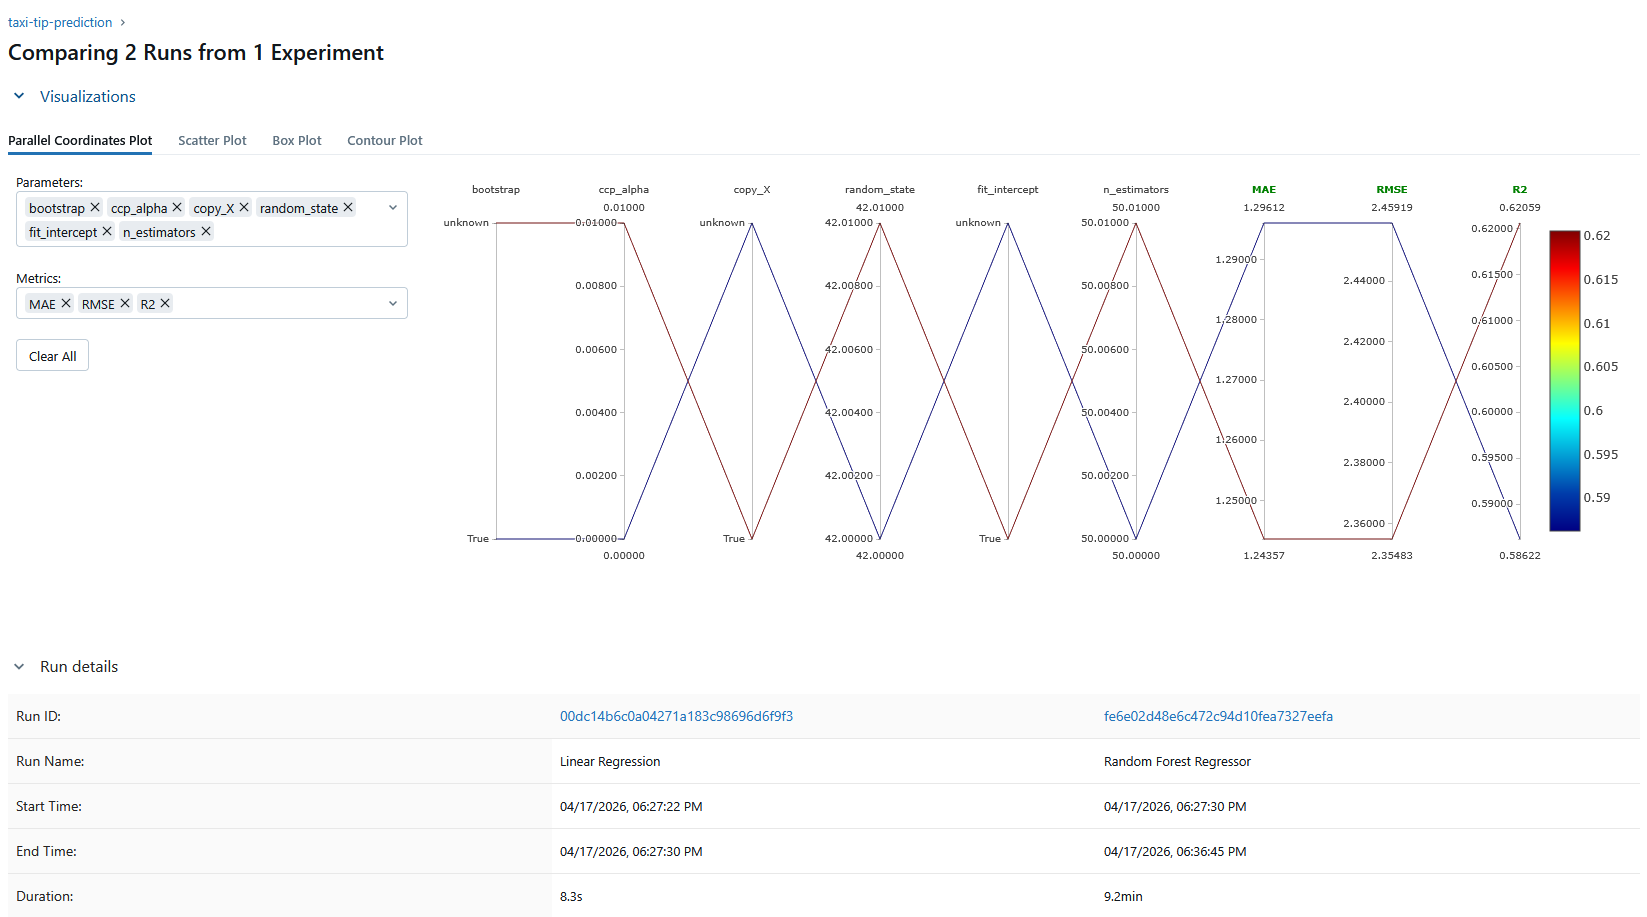
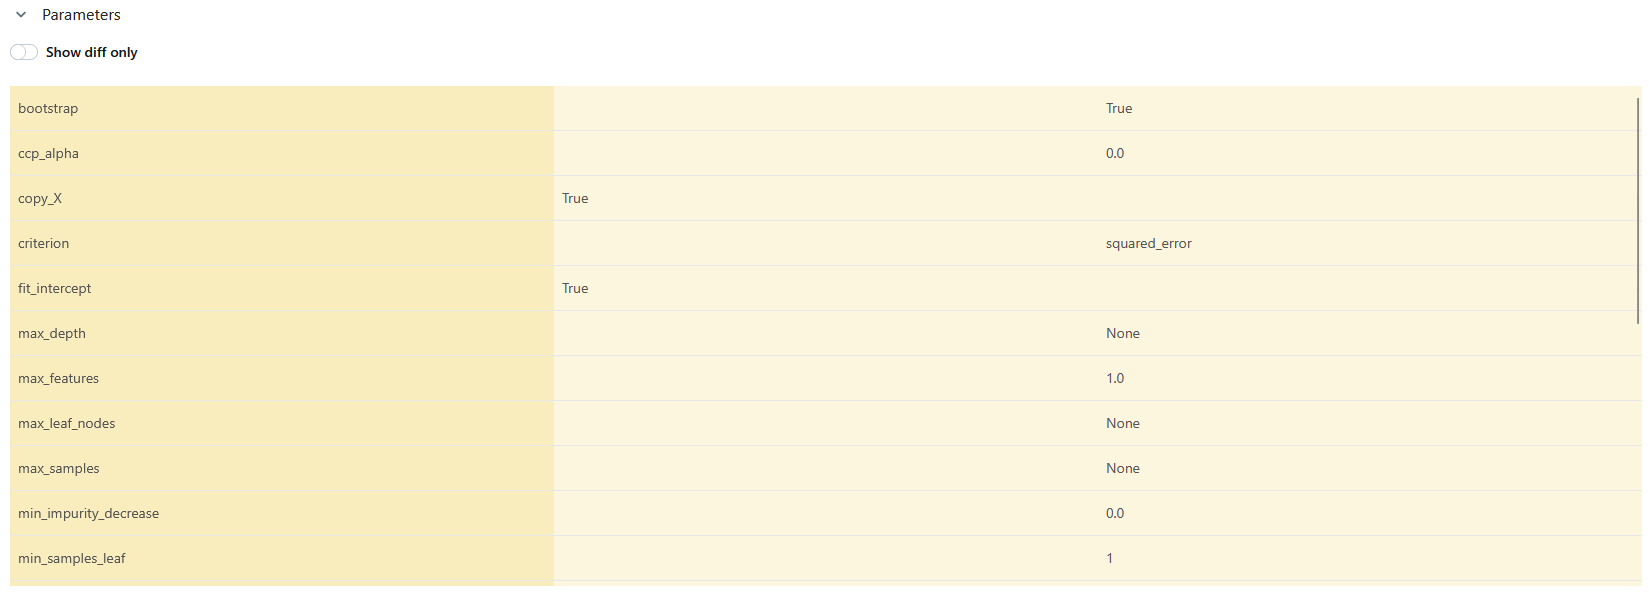
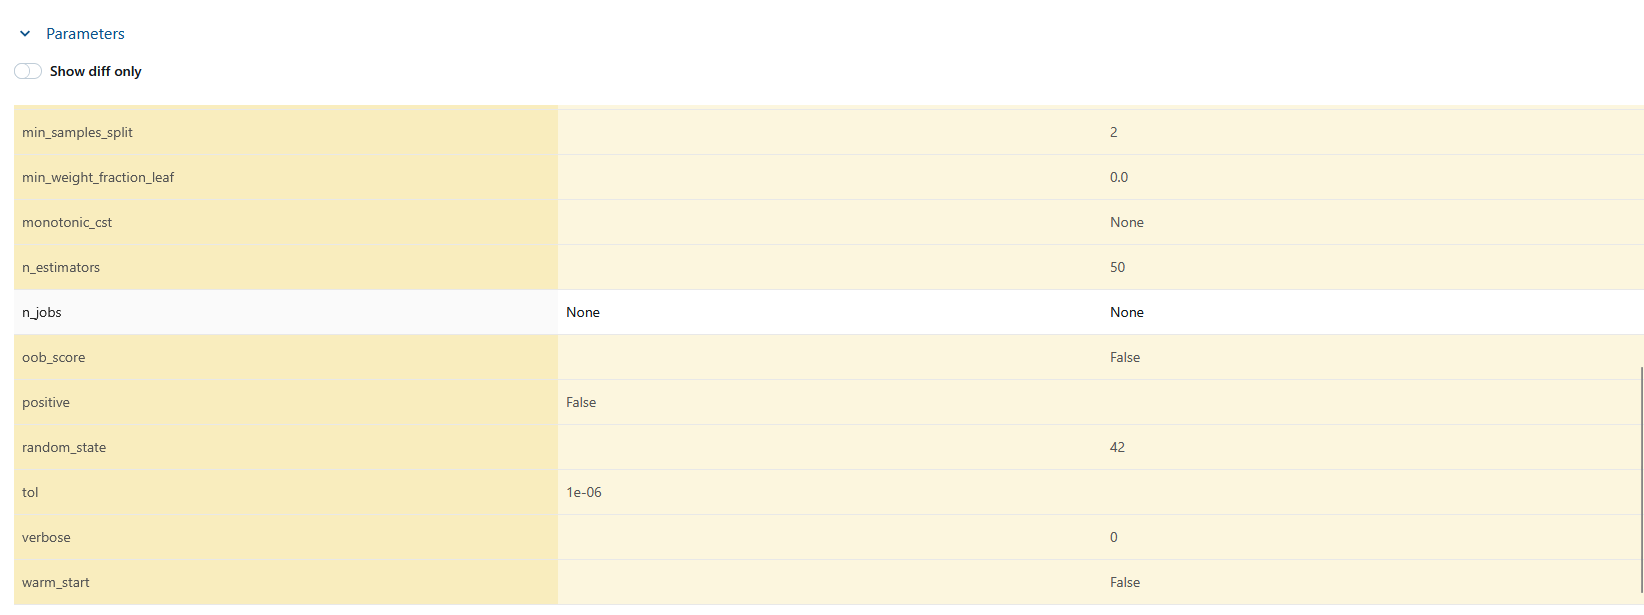
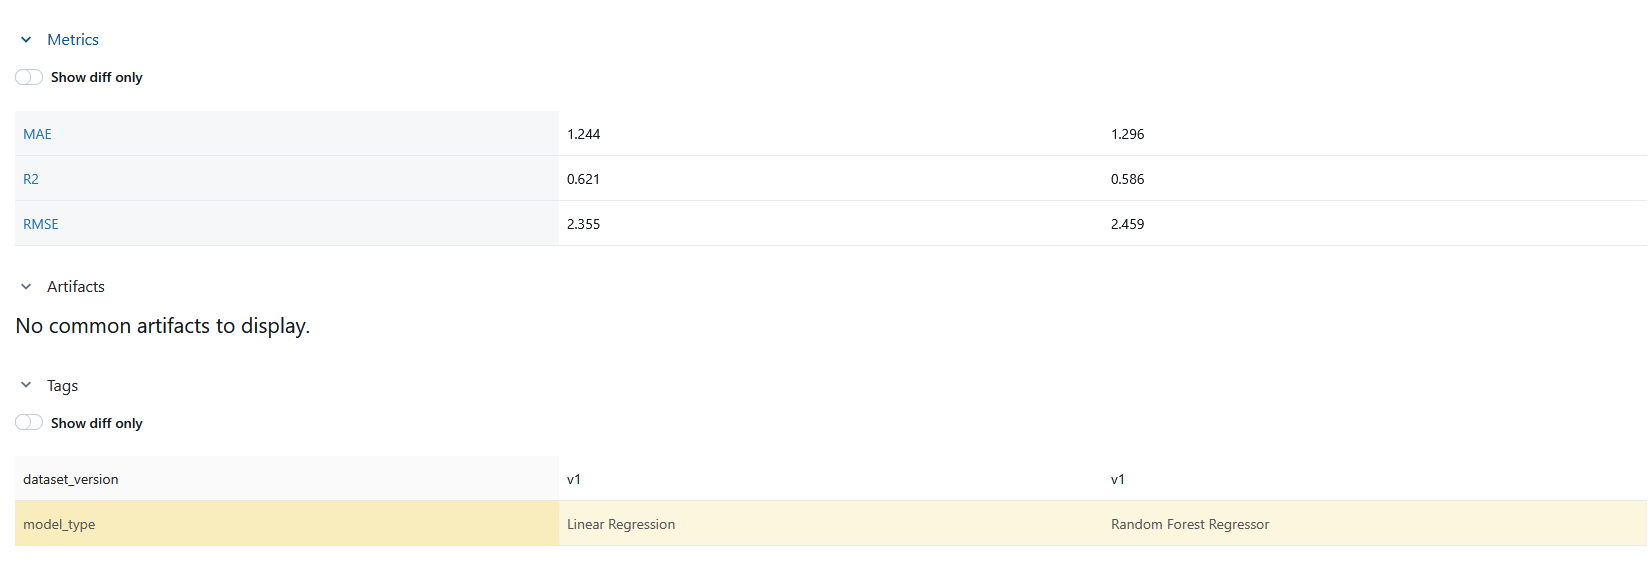

**Explanation:**
Based on the logged metrics in MLFlow, the Linear Regression model performed better than the Random Forest Regressor. The Linear Regression model had a lower MAE 1.244, RMSE 2.355 and a higher R2 of 0.621, whereas the Random Forest Regressor had a MAE of 1.296, R2 of 0.586 and RSME of 2.459. This indicates that the Linear Regression model is more accurate and reliable in terms of predictions for the sample of the dataset (300K rows used). However, it is important to note that due to using 300k sample and lower n_estimators (50) that could explain why the Random Forest Regressor performed worse. This sample was necessary due to computational restrictions.

In [ ]:
# Register the best-performing model (Linear Regression) in the MLflow Model Registry
from mlflow.tracking import MlflowClient

run_id="00dc14b6c0a04271a183c98696d6f9f3"
model_uri = f"runs:/{run_id}/model"
result = mlflow.register_model(
    model_uri=model_uri,
    name="taxi-tip-regressor"
)

# Set description and tags using the client
client = MlflowClient()
client.update_registered_model(
    name="taxi-tip-regressor",
    description="Linear Regression model for taxi tip prediction. Performance: MAE=1.244, RMSE=2.355, R2=0.621 on validation data."
)
client.set_model_version_tag(
    name="taxi-tip-regressor",
    version=result.version,
    key="model_type",
    value="Linear Regression"
)

client.update_model_version(
    name="taxi-tip-regressor",
    version=result.version,
    description="Linear Regression model for taxi tip prediction. Performance: MAE=1.244, RMSE=2.355, R2=0.621 on validation data."
)

print(f"Registered model version: {result.version}")

Registered model 'taxi-tip-regressor' already exists. Creating a new version of this model...
2026/04/17 19:54:34 WARNING mlflow.tracking._model_registry.fluent: Run with id 00dc14b6c0a04271a183c98696d6f9f3 has no artifacts at artifact path 'model', registering model based on models:/m-6000bb9d8e0045219e3d32cdaafd304c instead
2026/04/17 19:54:34 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: taxi-tip-regressor, version 3


Registering model from run_id: 00dc14b6c0a04271a183c98696d6f9f3
Registered model version: 3


Created version '3' of model 'taxi-tip-regressor'.


In [ ]:
# Load the model from the registry (latest version)
model_name = "taxi-tip-regressor"
model_uri = f"models:/{model_name}/latest"
loaded_model = mlflow.sklearn.load_model(model_uri)

sample_input = pd.DataFrame([{
    "passenger_count": 2,
    "payment_type": 1,
    "fare_amount": 20.0,
    "extra": 1.0,
    "mta_tax": 0.5,
    "tolls_amount": 0.0,
    "improvement_surcharge": 1.0,
    "congestion_surcharge": 2.5,
    "Airport_fee": 0.0,
    "trip_duration_minutes": 15.0,
    "trip_speed_mph": 12.0,
    "log_trip_distance": 1.2,
    "fare_per_mile": 6.5,
    "fare_per_minute": 1.33,
    "pickup_borough_Bronx": 0,
    "pickup_borough_Brooklyn": 0,
    "pickup_borough_EWR": 0,
    "pickup_borough_Manhattan": 1,
    "pickup_borough_N/A": 0,
    "pickup_borough_Queens": 0,
    "pickup_borough_Staten Island": 0,
    "pickup_borough_Unknown": 0,
    "dropoff_borough_Bronx": 0,
    "dropoff_borough_Brooklyn": 0,
    "dropoff_borough_EWR": 0,
    "dropoff_borough_Manhattan": 1,
    "dropoff_borough_N/A": 0,
    "dropoff_borough_Queens": 0,
    "dropoff_borough_Staten Island": 0,
    "dropoff_borough_Unknown": 0
}])

prediction = loaded_model.predict(sample_input)
print("Predicted tip_amount:", round(float(prediction[0]), 2))

Predicted tip_amount: 4.22


## Part 2: Model Serving with FastAPI 

Swagger UI Documentation

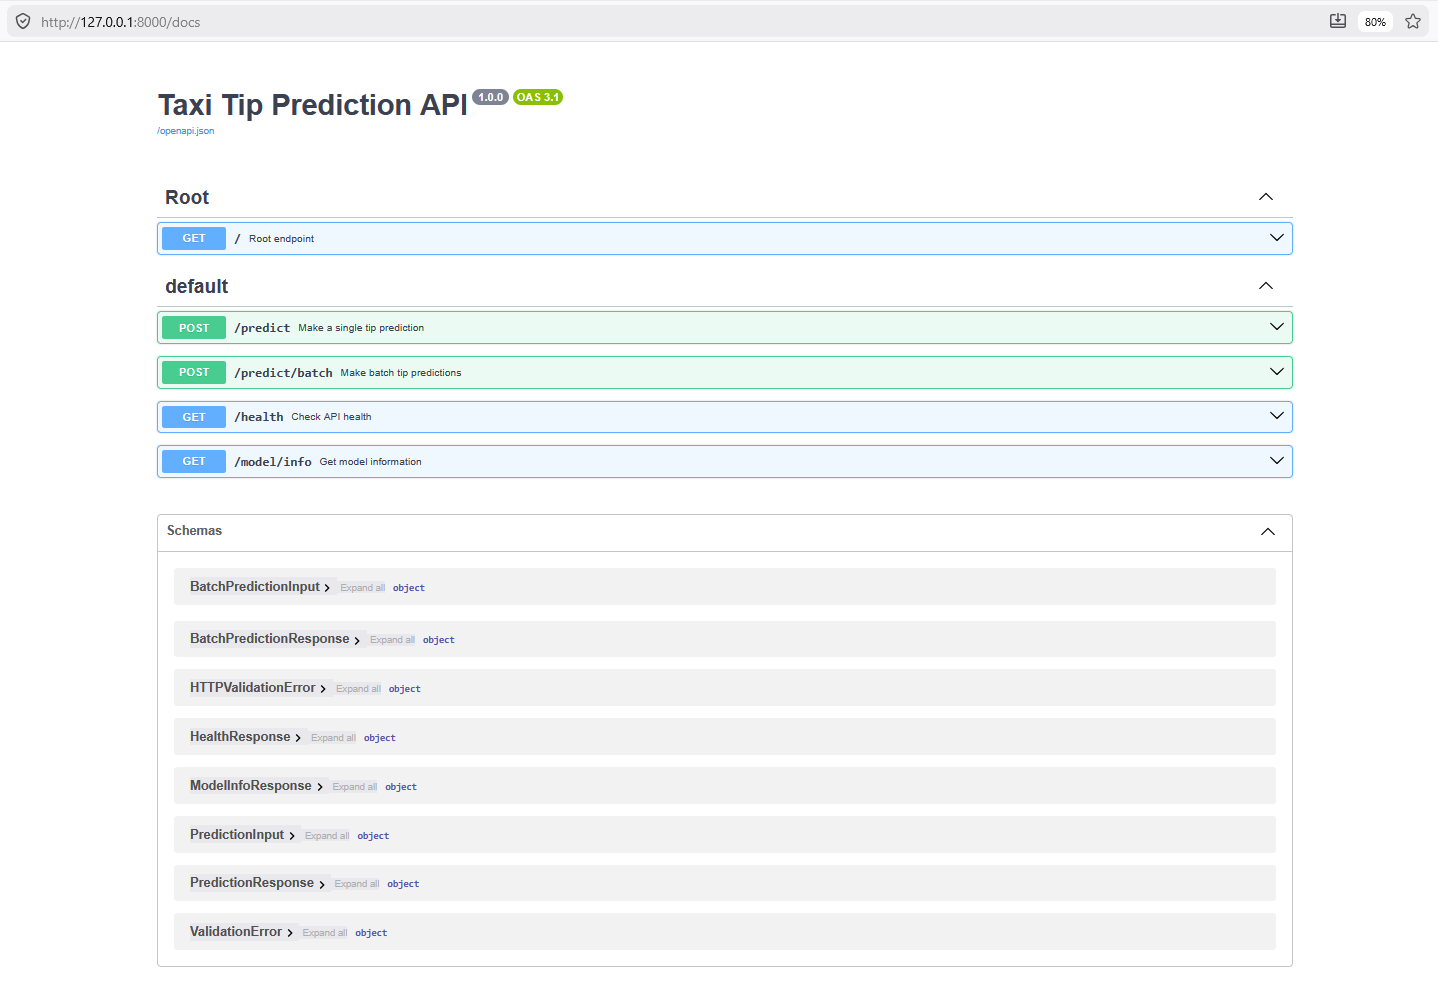

Root Endpoint
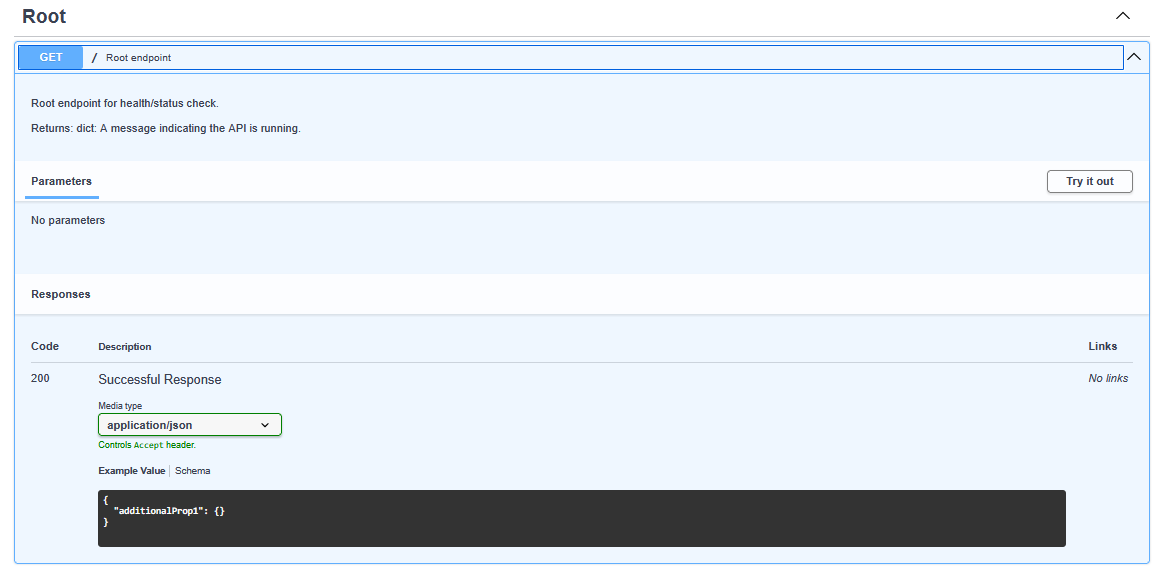

Single Prediction Endpoint
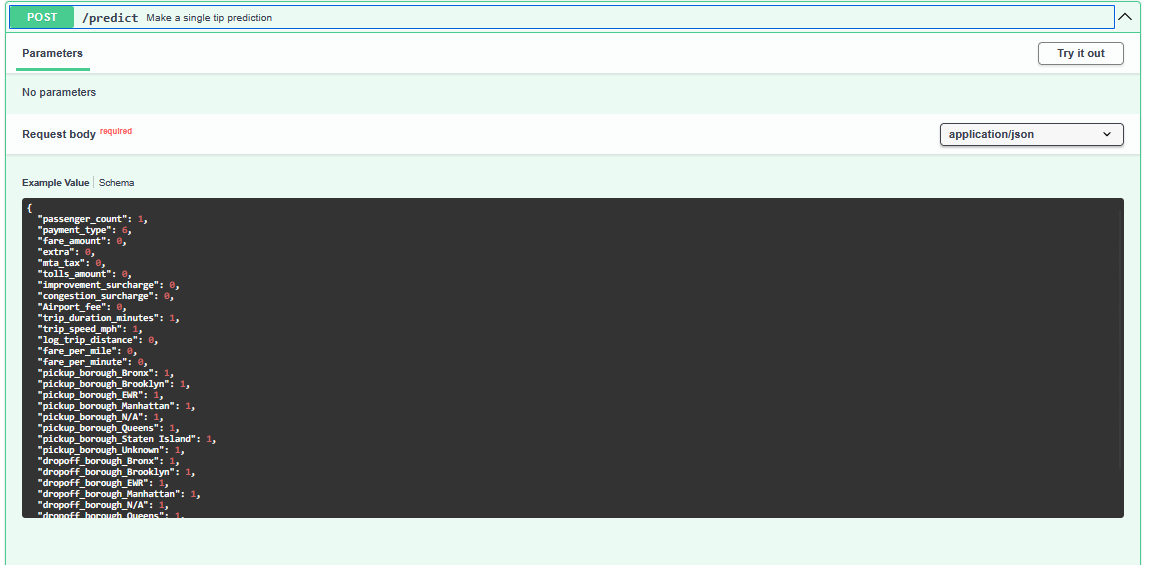
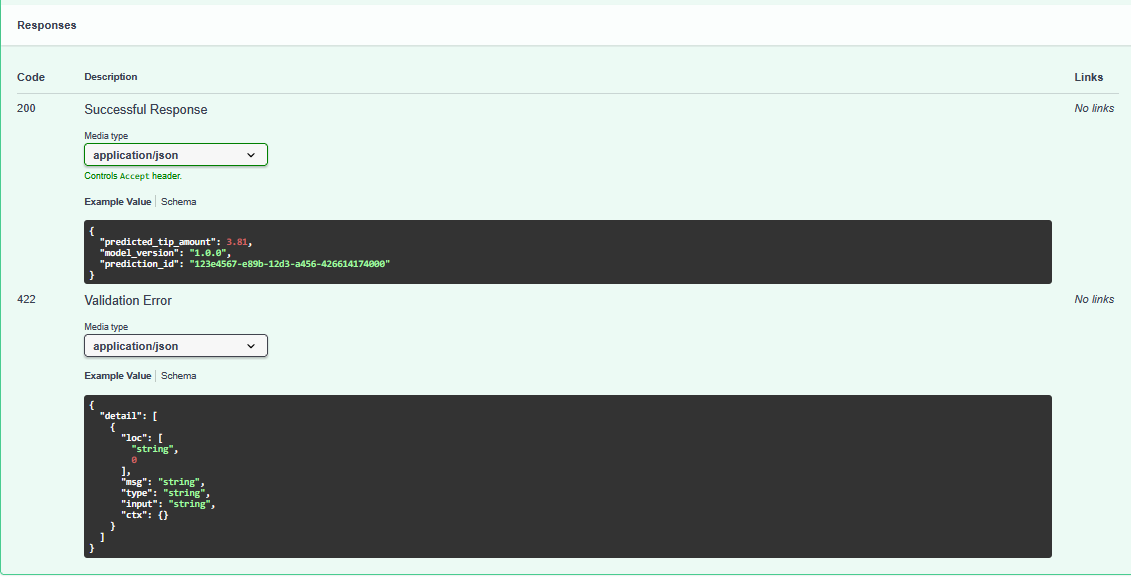

Batch Endpoint
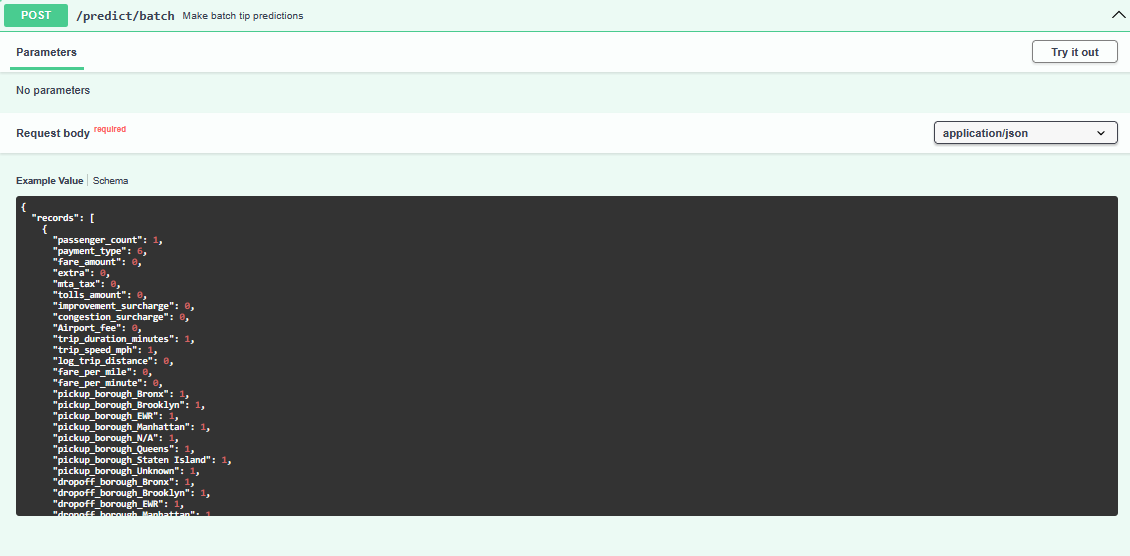
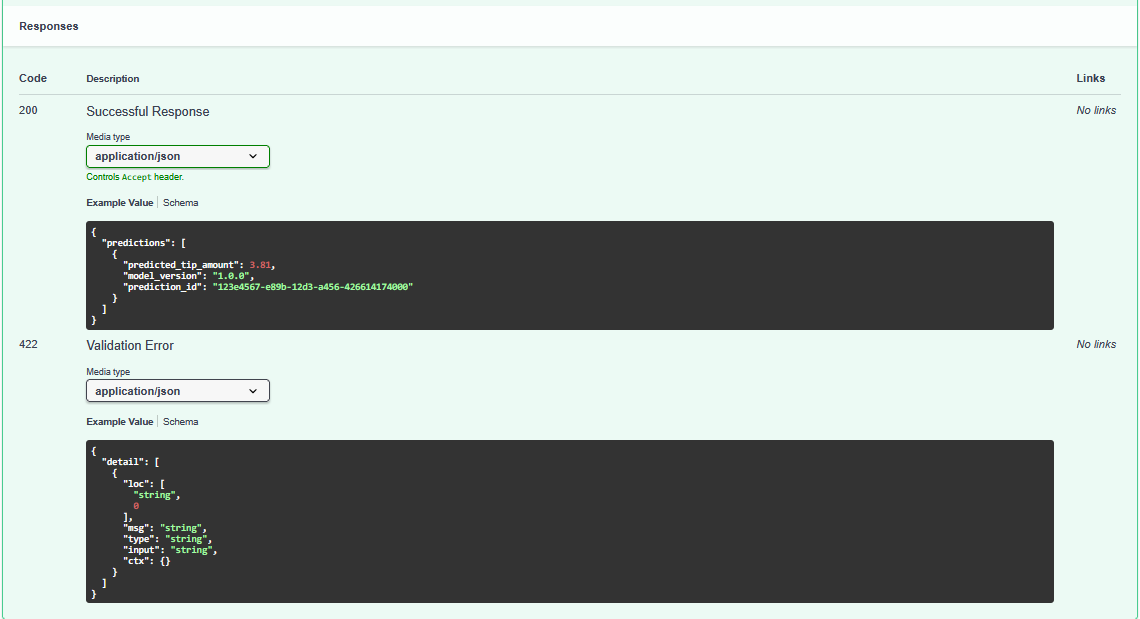

Health Endpoint
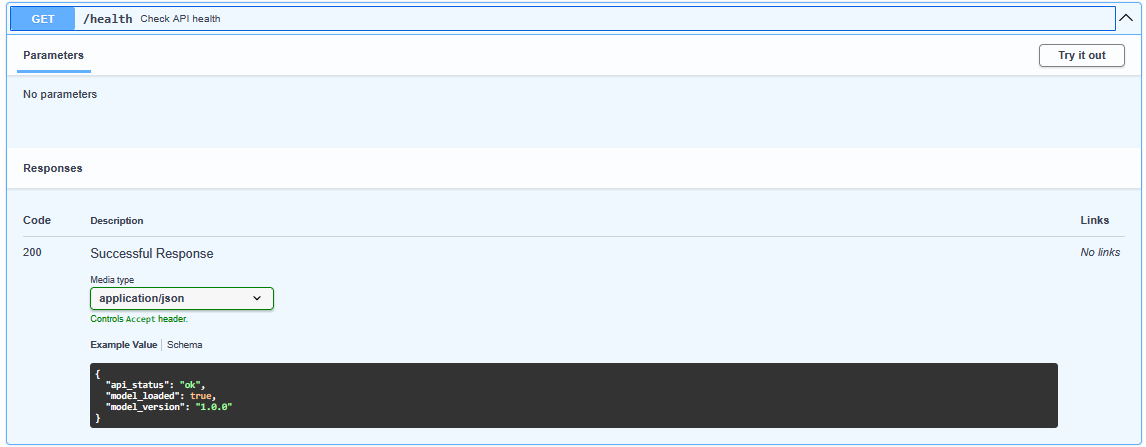

Model Info Endpoint
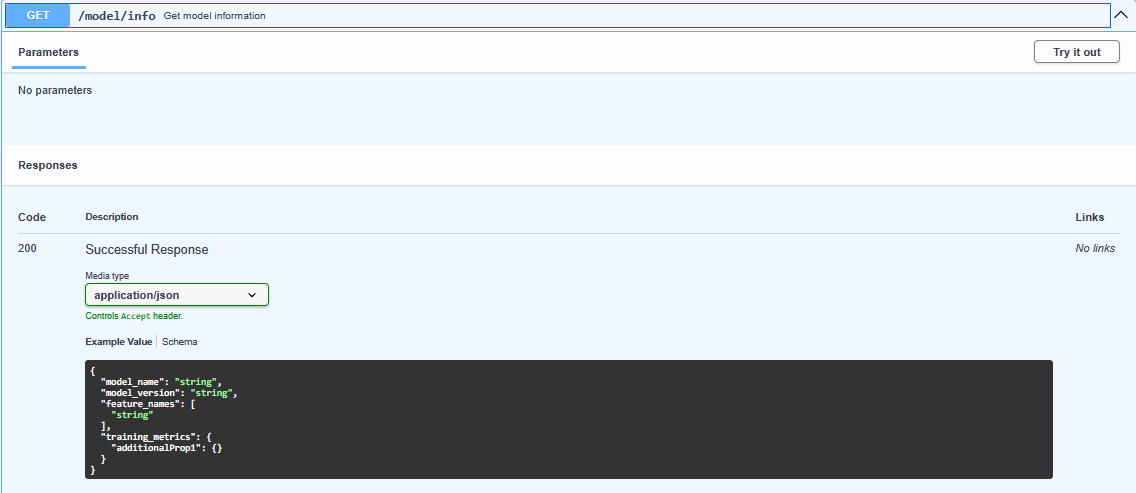

API Testing

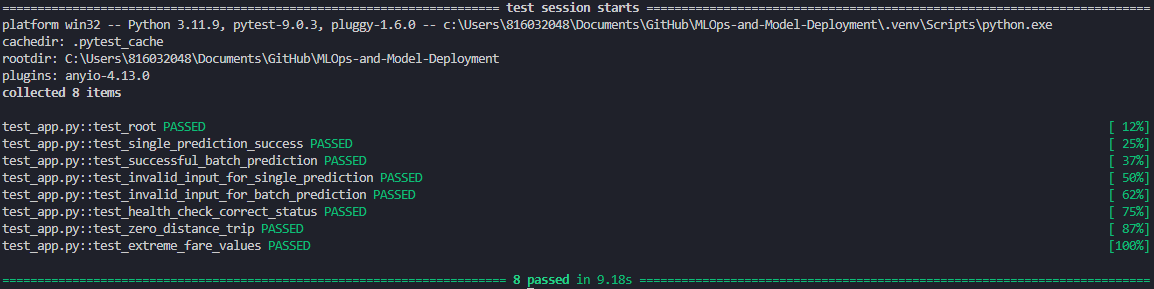

## Part 3: Containerization with Docker

####  Dockerfile & Image Building

Built Docker image and the image size:


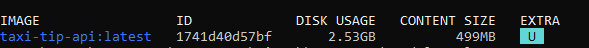

<!-- Run the container and verify the API is accessible by making a test prediction from outside the container (using curl or Python requests)  -->

After running: 'docker run -p 8000:8000 taxi-tip-api'. The API was successfully verified from outside the container by accessing the Swagger UI at /docs and sending a test POST /predict request, which returned a successful JSON response containing the predicted tip amount, model version, and prediction ID.

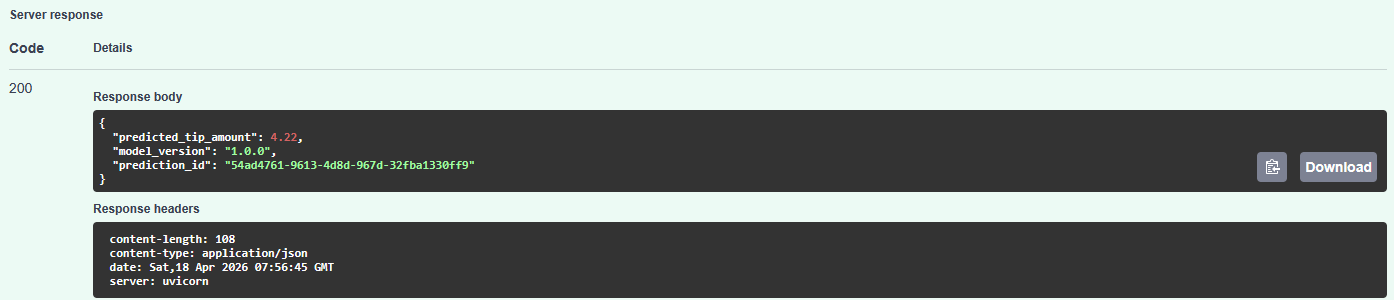

Sample prediction requests to the containerized API using Invoke-RestMethod
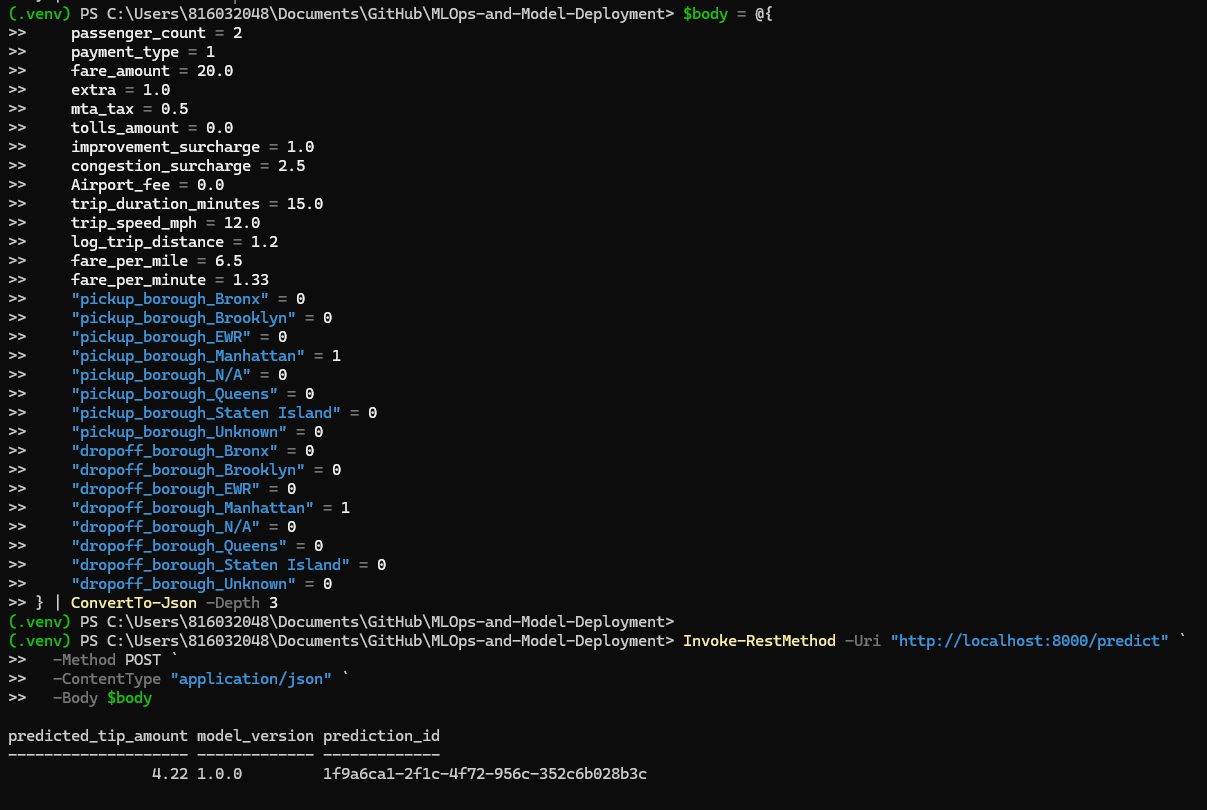
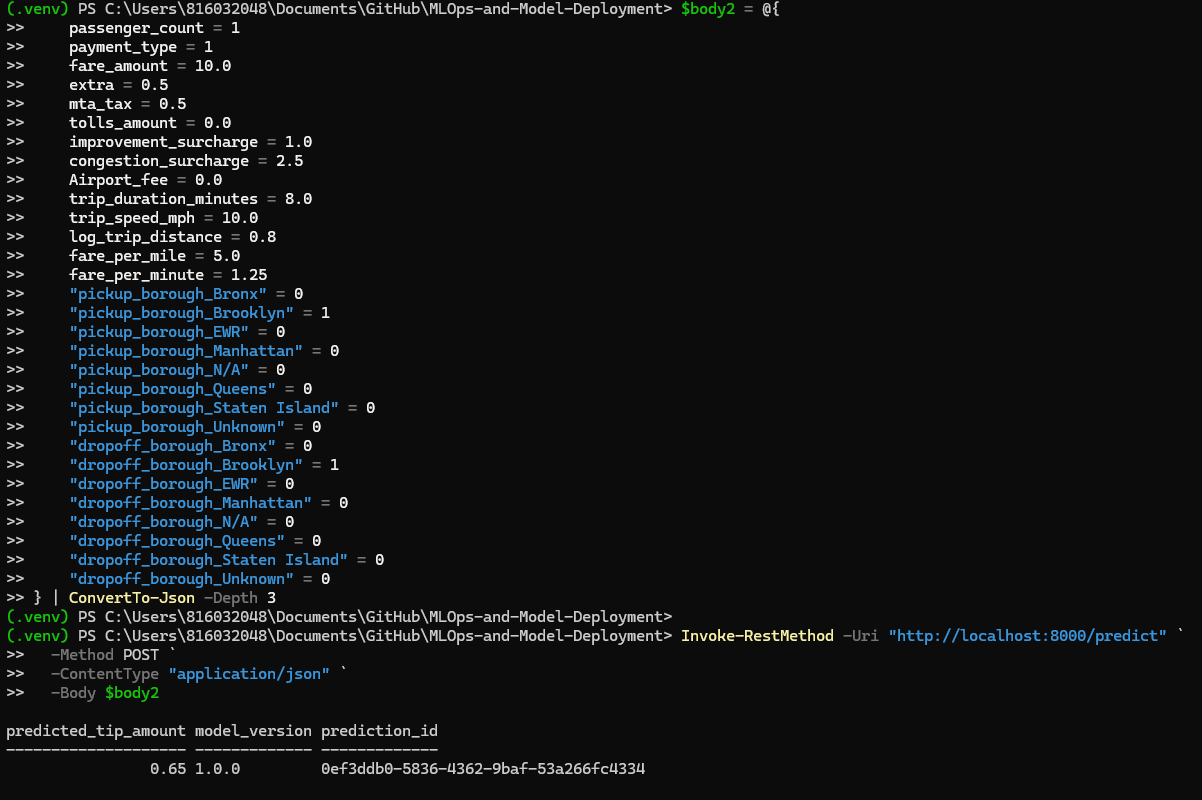
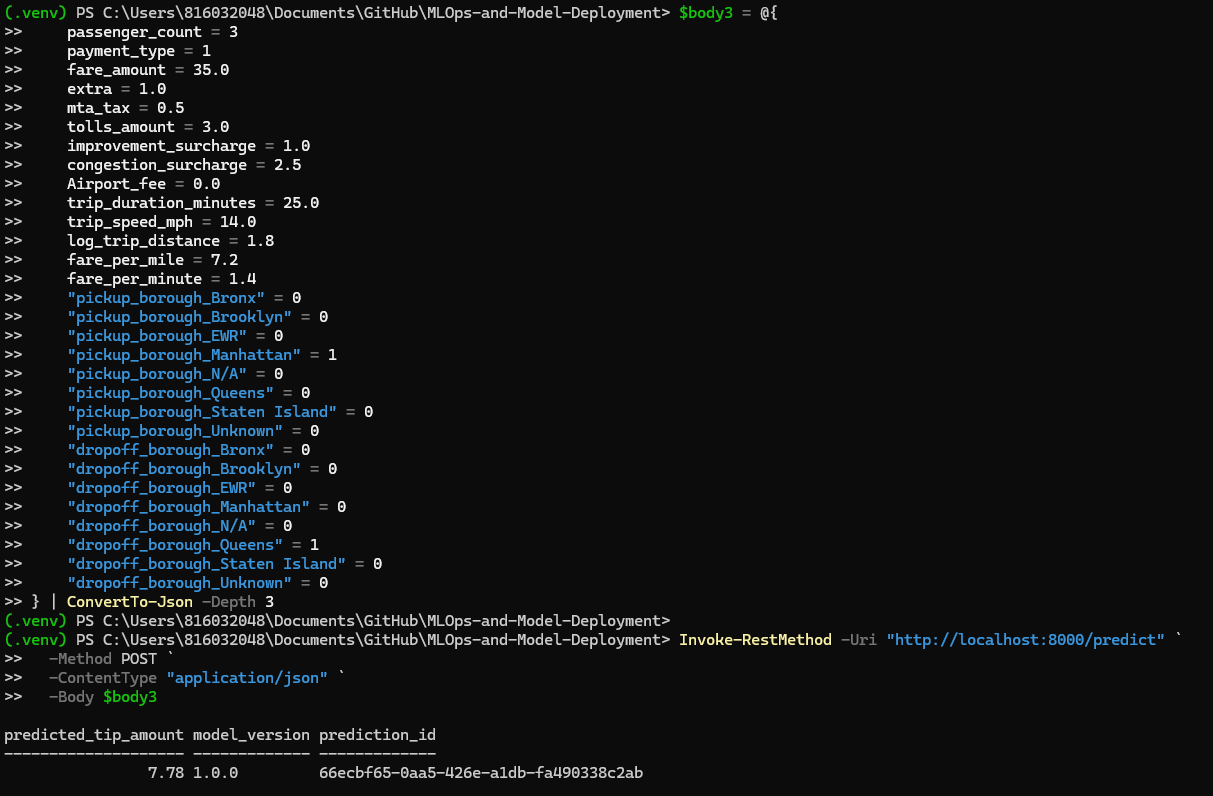

Batch Prediction

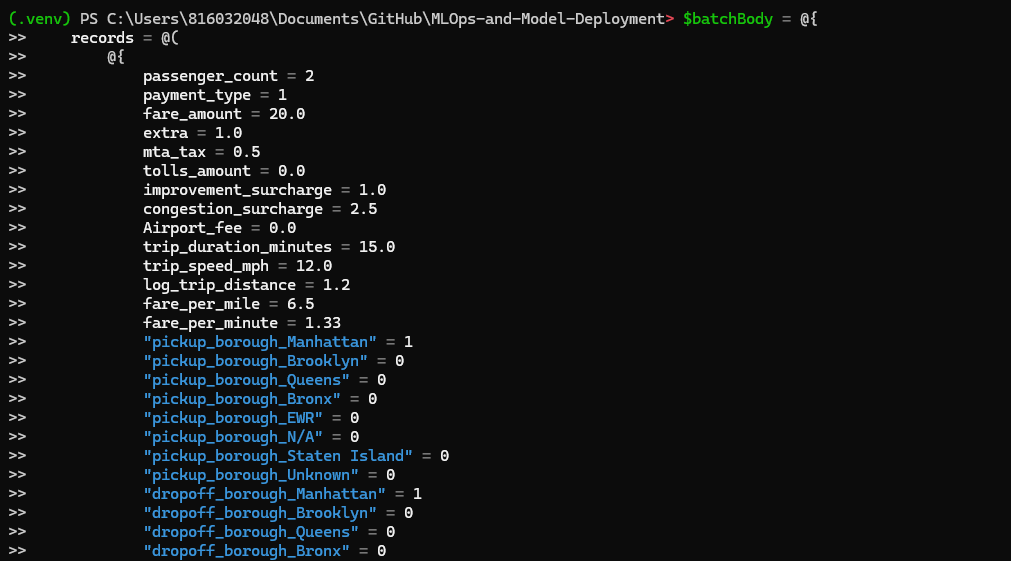
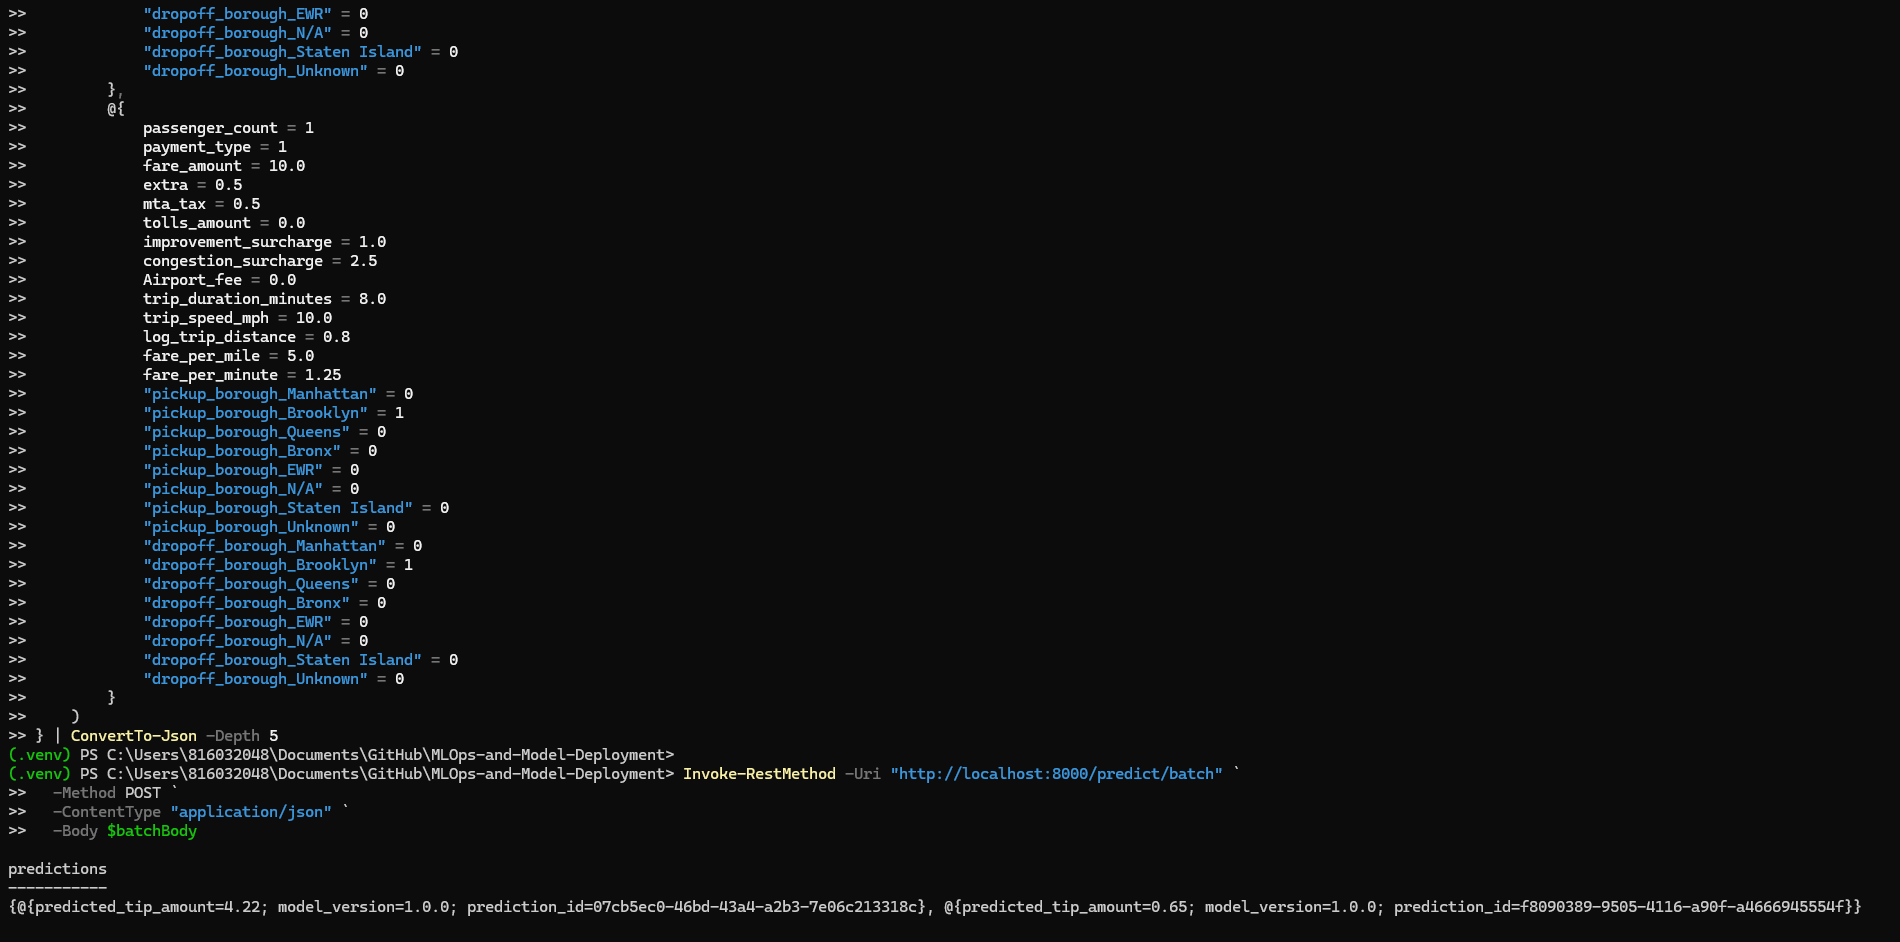

Health Check

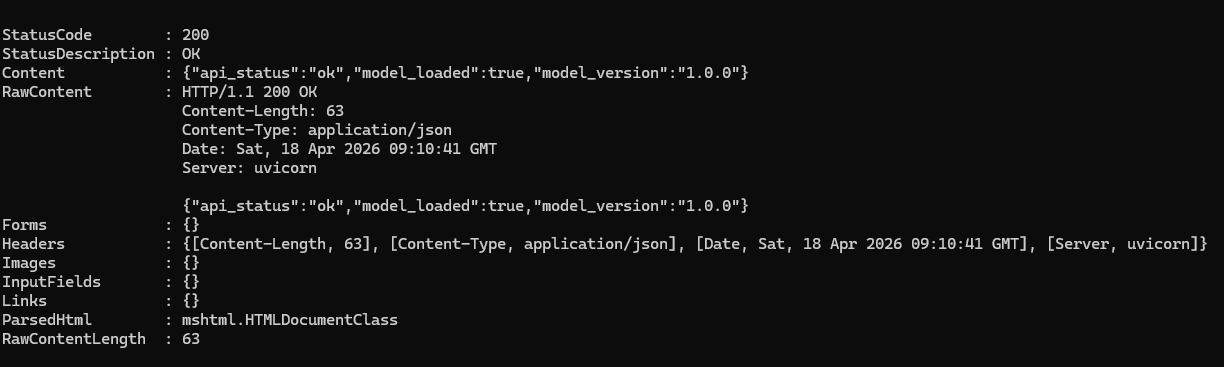

Clean shut down

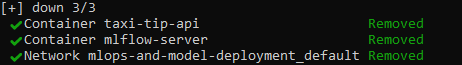

The Dockerfile packages the FastAPI application and trained model into a container using the lightweight python:3.11-slim base image to keep the image size small. Environment variables (PYTHONDONTWRITEBYTECODE=1 and PYTHONUNBUFFERED=1) are set to prevent unnecessary .pyc files and ensure logs are printed immediately. The working directory is set to /app, and dependencies are installed from requirements.txt. Only the required files (app.py and the models/ folder) are copied into the container. Port 8000 is exposed, and the application is started using uvicorn app:app --host 0.0.0.0 --port 8000. The container is built with docker build -t taxi-tip-api . and run using docker run -p 8000:8000 taxi-tip-api to make the API accessible externally.

The project was configured with Docker Compose using an api service and an mlflow service. The api service builds from the local Dockerfile, maps port 8000:8000, and sets MODEL_PATH=/app/models/linear_regression_artifact.pkl so the FastAPI app can load the saved model artifact inside the container. The mlflow service runs from the prebuilt image ghcr.io/mlflow/mlflow:v2.12.1, maps port 5000:5000, and launches an MLflow server on port 5000. The Docker image for the API had a content size of 499 MB, and the deployment was run with docker compose up --build and shut down with docker compose down.

AI USAGE


Used chatgpt:
- to confirm if i satisfied the requirements
- to understand how to setup mlflow and what commands i need to run
- how to show proper examples in the swagger doc instead of showing string in the example since it seemed to vague for documentation
- to help with debugging when i faced issues when trying out some api routes or when some tests were failing
- to understand how to setup the dockerfile for the FastAPI applications
- to resolve issue i had with connecting to docker
- to understand further with how docker works
- to resolve issue i had using curl ended up using invoke rest method
- used to generate request body samples to make predictions
- readme.md